In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [3]:
img_size = (224,224)
batch_size = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
num_classes = train_data.num_classes

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x
x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs=base_model.input, outputs=output)

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ModelCheckpoint("../models/resnet50_best.h5", monitor="val_loss", save_best_only=True)
]

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
result = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0474 - loss: 6.8275

110/110 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.0669 - loss: 6.4793 - val_accuracy: 0.1947 - val_loss: 5.2001 - learning_rate: 1.0000e-04
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1434 - loss: 5.5688

110/110 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.1624 - loss: 5.4983 - val_accuracy: 0.3600 - val_loss: 4.6857 - learning_rate: 1.0000e-04
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2472 - loss: 5.0742

110/110 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.2687 - loss: 5.0150 - val_accuracy: 0.4080 - val_loss: 4.3677 - learning_rate: 1.0000e-04
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2975 - loss: 4.8482

110/110 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.3110 - loss: 4.7597 - val_accuracy: 0.4907 - val_loss: 4.1371 - learning_rate: 1.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3707 - loss: 4.4282

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5666 - loss: 3.2993 - val_accuracy: 0.6667 - val_loss: 3.0940 - learning_rate: 1.0000e-04
Epoch 17/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5845 - loss: 3.2426

110/110 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5855 - loss: 3.2365 - val_accuracy: 0.6613 - val_loss: 3.0478 - learning_rate: 1.0000e-04
Epoch 18/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6046 - loss: 3.1706

110/110 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6192 - loss: 3.1270 - val_accuracy: 0.6747 - val_loss: 2.9901 - learning_rate: 1.0000e-04
Epoch 19/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6101 - loss: 3.1169

110/110 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6272 - loss: 3.0606 - val_accuracy: 0.6907 - val_loss: 2.9392 - learning_rate: 1.0000e-04
Epoch 20/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6203 - loss: 3.0262

110/110 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.6112 - loss: 3.0100 - val_accuracy: 0.6907 - val_loss: 2.8929 - learning_rate: 1.0000e-04


In [8]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6329 - loss: 2.9817

110/110 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.6261 - loss: 2.9731 - val_accuracy: 0.6987 - val_loss: 2.8732 - learning_rate: 3.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6491 - loss: 2.8970

110/110 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6484 - loss: 2.8968 - val_accuracy: 0.7120 - val_loss: 2.8539 - learning_rate: 3.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6656 - loss: 2.8271

110/110 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.6655 - loss: 2.8457 - val_accuracy: 0.7253 - val_loss: 2.8010 - learning_rate: 3.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7061 - loss: 2.6934

110/110 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6993 - loss: 2.7094 - val_accuracy: 0.7413 - val_loss: 2.7622 - learning_rate: 3.0000e-05
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7092 - loss: 2.6566

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8531 - loss: 1.9698 - val_accuracy: 0.7600 - val_loss: 2.3902 - learning_rate: 3.0000e-05
Epoch 24/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8479 - loss: 1.9570

110/110 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8582 - loss: 1.9180 - val_accuracy: 0.7733 - val_loss: 2.3534 - learning_rate: 3.0000e-05
Epoch 25/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8445 - loss: 1.9295 - val_accuracy: 0.7707 - val_loss: 2.3611 - learning_rate: 3.0000e-05
Epoch 26/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8826 - loss: 1.8455

110/110 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8656 - loss: 1.8824 - val_accuracy: 0.7707 - val_loss: 2.3344 - learning_rate: 3.0000e-05
Epoch 27/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8556 - loss: 1.8638

110/110 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8651 - loss: 1.8577 - val_accuracy: 0.7813 - val_loss: 2.2945 - learning_rate: 3.0000e-05
Epoch 28/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8708 - loss: 1.8190

110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8639 - loss: 1.8446 - val_accuracy: 0.7840 - val_loss: 2.2897 - learning_rate: 3.0000e-05
Epoch 29/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8674 - loss: 1.7934 - val_accuracy: 0.7787 - val_loss: 2.2964 - learning_rate: 3.0000e-05
Epoch 30/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8696 - loss: 1.7695 - val_accuracy: 0.7520 - val_loss: 2.2989 - learning_rate: 3.0000e-05


- Train 86
- Test 80

In [9]:
test_loss, test_acc = model.evaluate(test_data)
print(test_acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 918ms/step - accuracy: 0.8000 - loss: 2.1312
0.800000011920929


In [10]:
def prediction():
    model = models.load_model("../models/VGG16_best.h5")

    img_path = "../smartvision_dataset/detection/images/image_000002.jpg"
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)

    class_indices = train_data.class_indices
    class_names = list(class_indices.keys())

    predicted_class = class_names[np.argmax(predictions)]

    return predicted_class

In [11]:
pred = prediction()
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


'person'

In [12]:
model = models.load_model("../models/resnet50_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step 
               precision    recall  f1-score   support

     airplane       0.88      0.93      0.90        15
          bed       0.69      0.60      0.64        15
        bench       0.71      0.67      0.69        15
      bicycle       0.85      0.73      0.79        15
         bird       1.00      0.80      0.89        15
       bottle       0.75      0.80      0.77        15
         bowl       0.53      0.60      0.56        15
          bus       0.75      0.80      0.77        15
         cake       0.87      0.87      0.87        15
          car       0.74      0.93      0.82        15
          cat       0.70      0.93      0.80        15
        chair       0.88      0.93      0.90        15
        couch       0.73      0.73      0.73        15
          cow       0.74      0.93      0.82        15
          cup       0.90      0.60      0.72        15
          dog       0.77      0.67      0.71        15
     elephant       0.93

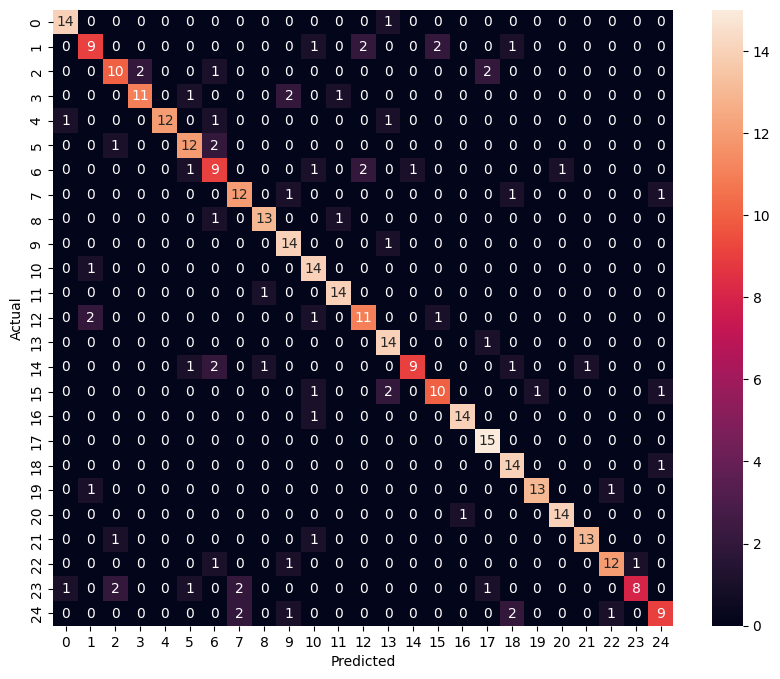

In [13]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()